DATASET LOADED SUCCESSFULLY

Dataset Shape:
Rows: 7324
Columns: 7

Column Names:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

First 5 Rows:
                        date      open      high       low     close  \
0  1996-01-01 00:00:00+05:30  7.319124  7.358397  7.270925  7.345901   
1  1996-01-02 00:00:00+05:30  7.328050  7.363753  7.235222  7.288776   
2  1996-01-03 00:00:00+05:30  7.408381  7.745775  7.328050  7.344116   
3  1996-01-04 00:00:00+05:30  7.274495  7.297702  7.178097  7.276280   
4  1996-01-05 00:00:00+05:30  7.247718  7.247718  7.163816  7.226296   

   adj_close     volume  
0   3.353593  104121369  
1   3.327513  168743308  
2   3.352778  209323879  
3   3.321809  216900264  
4   3.298990  166708467  

Last 5 Rows:
                           date         open         high          low  \
7319  2025-02-21 00:00:00+05:30  1228.699951  1240.000000  1222.150024   
7320  2025-02-24 00:00:00+05:30  1216.550049  1223.250000  1210.500000   
7321  2025-02-2

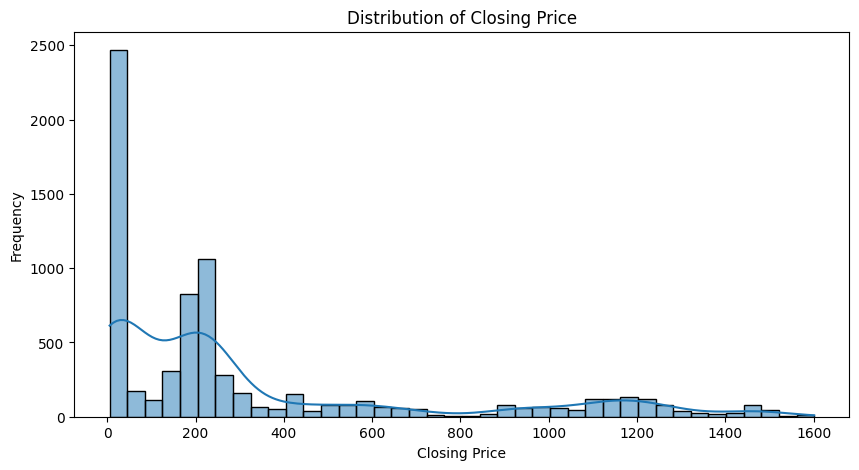

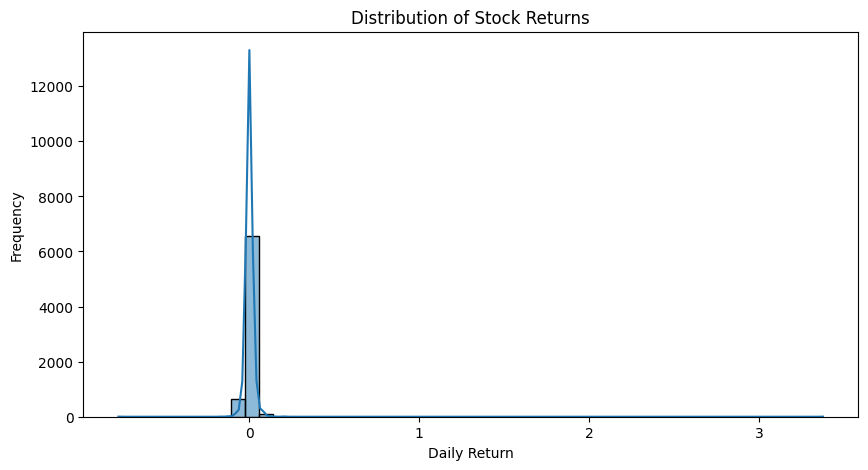

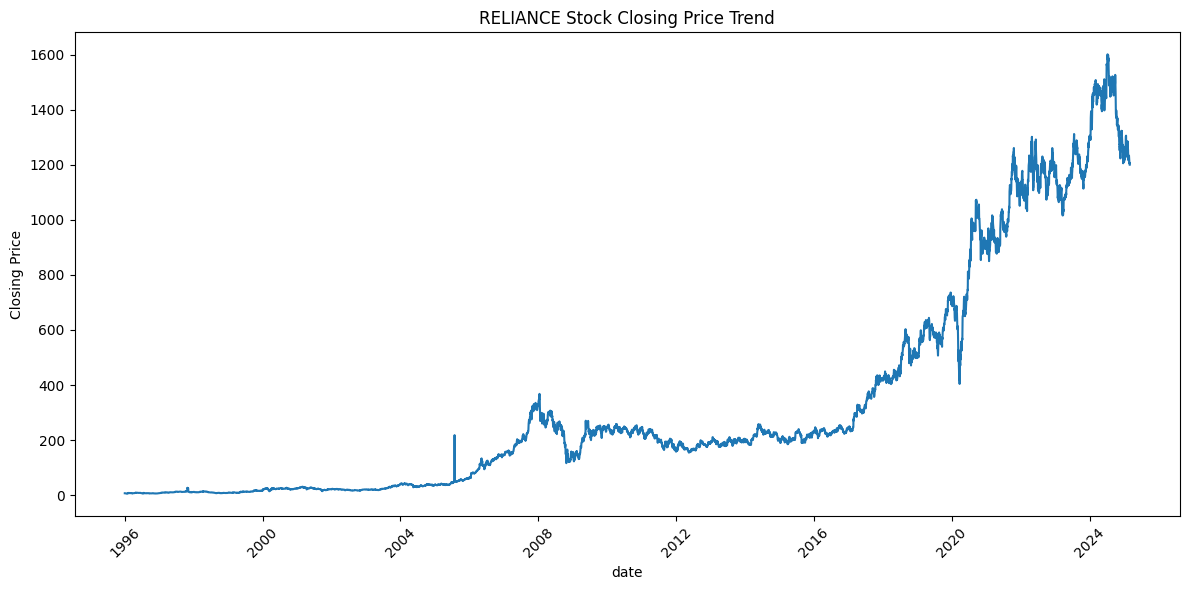

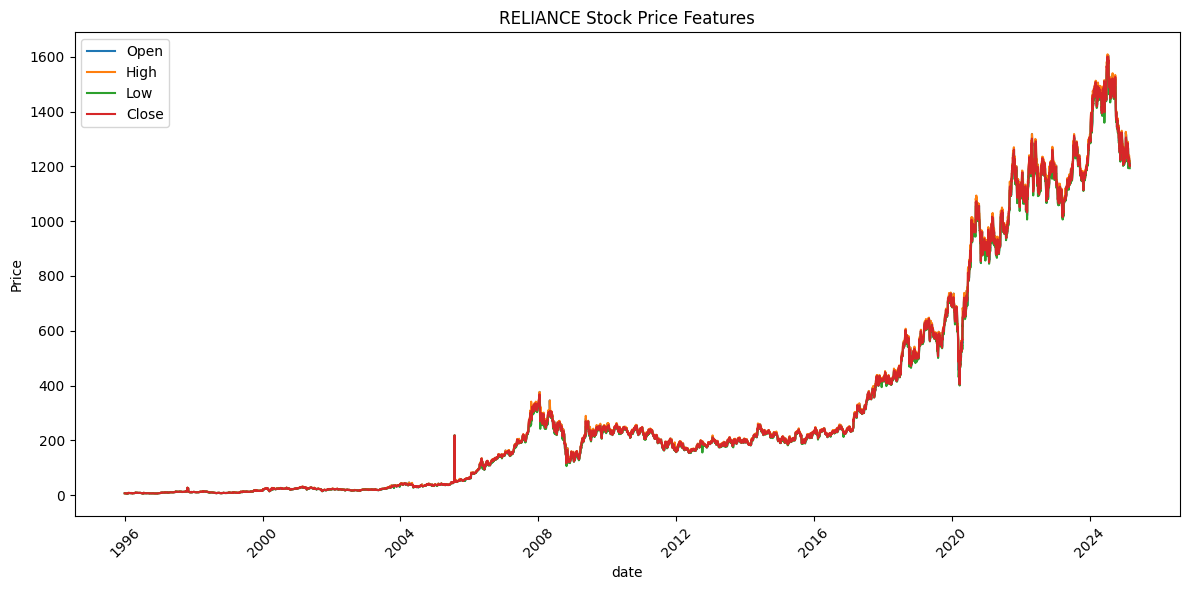

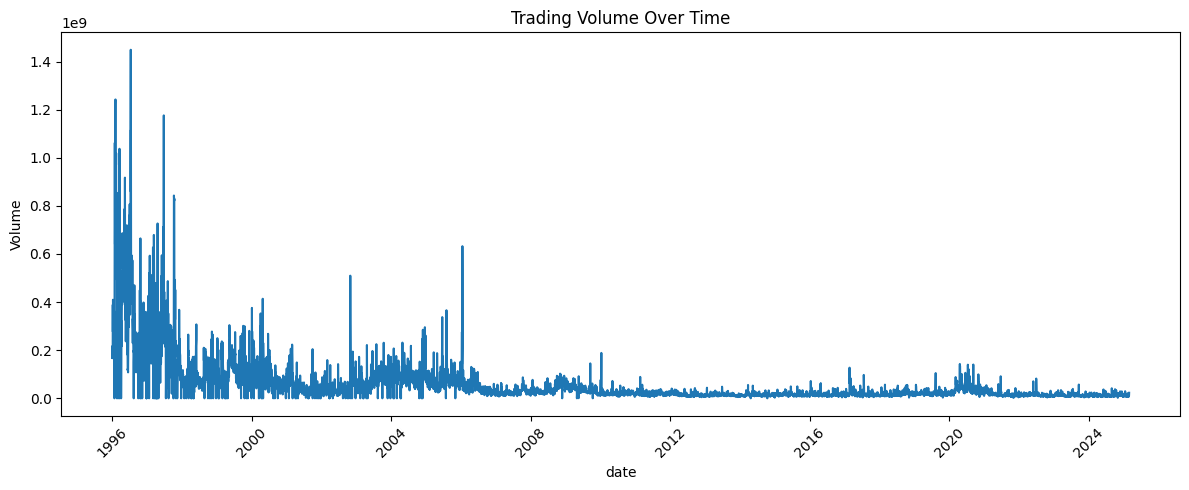

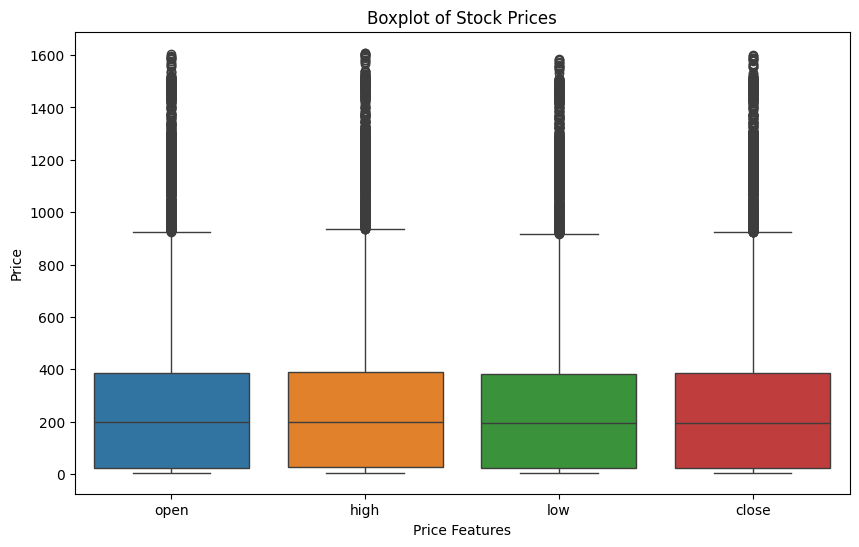

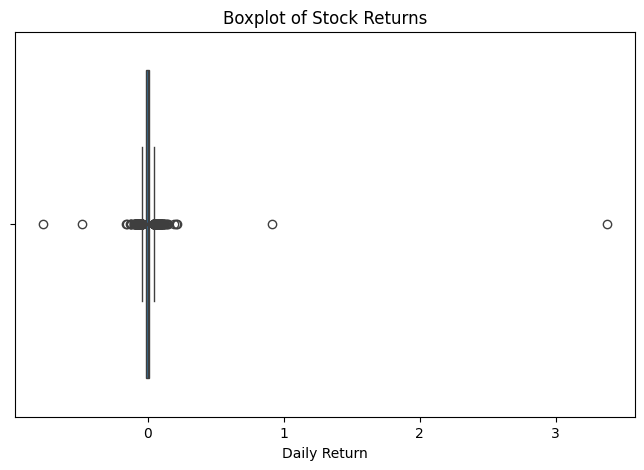

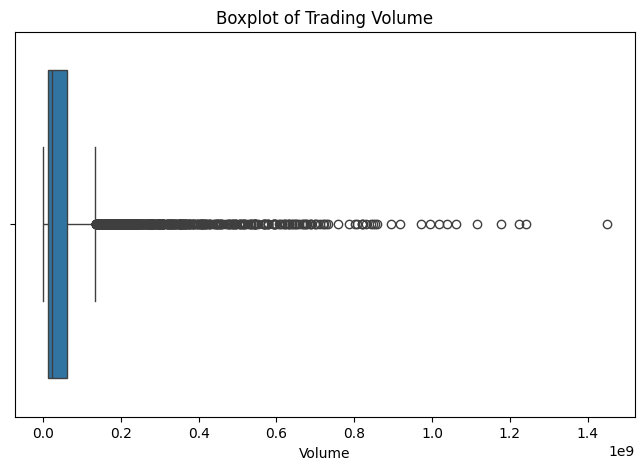


CORRELATION MATRIX
               open      high       low     close  adj_close    volume  \
open       1.000000  0.999915  0.999904  0.999819   0.999545 -0.306281   
high       0.999915  1.000000  0.999881  0.999926   0.999618 -0.306103   
low        0.999904  0.999881  1.000000  0.999922   0.999689 -0.306308   
close      0.999819  0.999926  0.999922  1.000000   0.999727 -0.306157   
adj_close  0.999545  0.999618  0.999689  0.999727   1.000000 -0.298528   
volume    -0.306281 -0.306103 -0.306308 -0.306157  -0.298528  1.000000   
Return    -0.008426 -0.006109 -0.006012 -0.003934  -0.004708  0.035612   

             Return  
open      -0.008426  
high      -0.006109  
low       -0.006012  
close     -0.003934  
adj_close -0.004708  
volume     0.035612  
Return     1.000000  


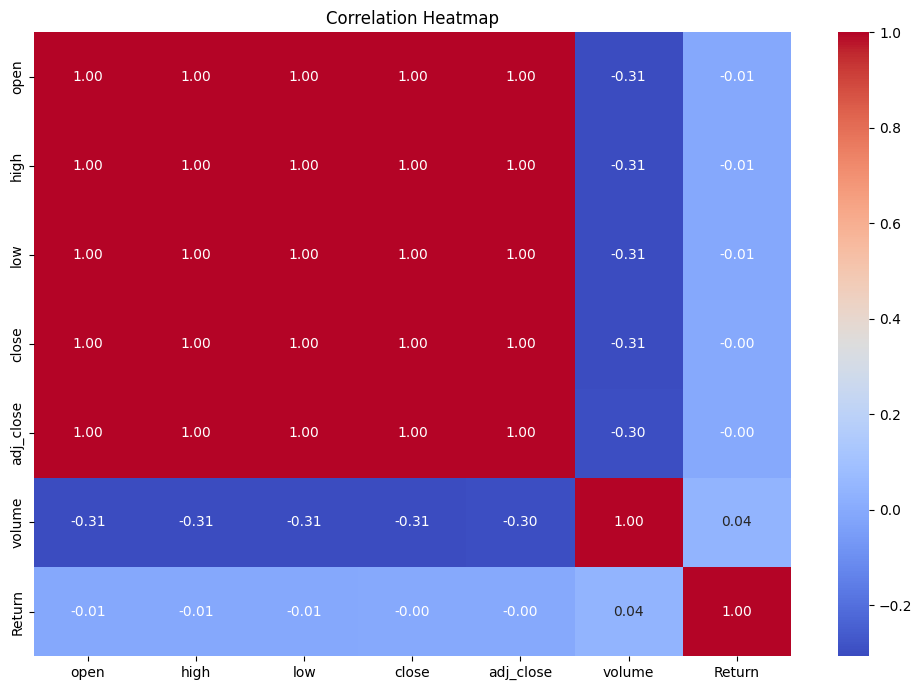

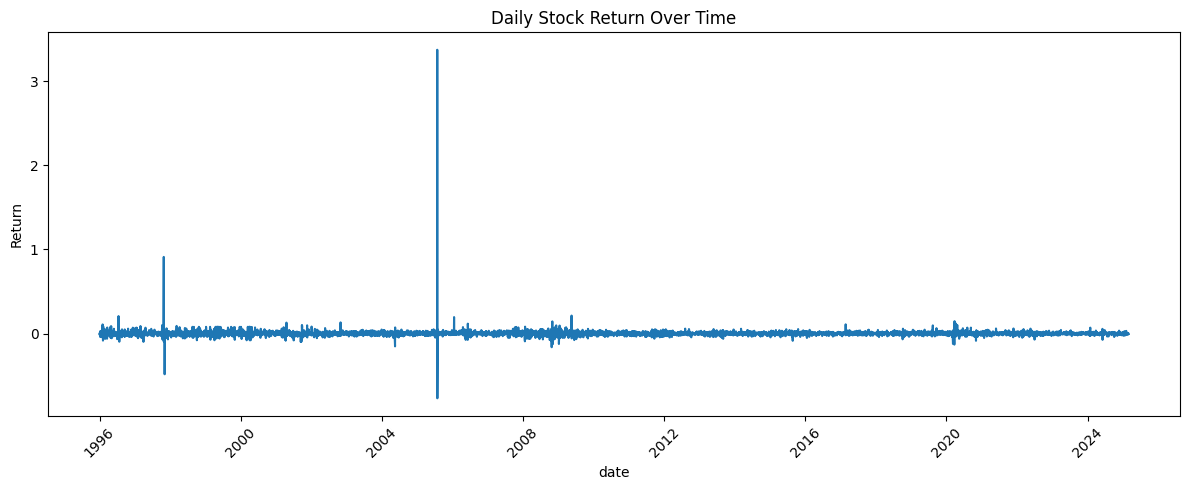

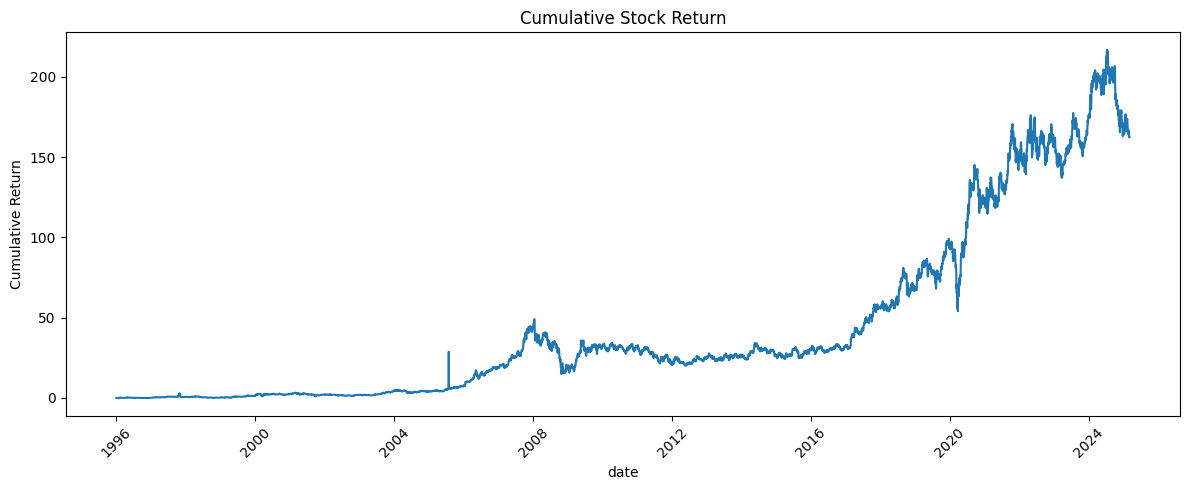


OUTLIER ANALYSIS
Lower Limit: -0.043694489489373295
Upper Limit: 0.044500488553372936
Number of Return Outliers: 356

FINAL DATASET INFORMATION
Rows after preprocessing: 7323
Columns after preprocessing: 9

Final Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'Return', 'Cumulative_Return']

Final Missing Values:
date                 0
open                 0
high                 0
low                  0
close                0
adj_close            0
volume               0
Return               0
Cumulative_Return    0
dtype: int64

EDA COMPLETED SUCCESSFULLY!


In [ ]:
# ============================================================
# EDA - RELIANCE.NS STOCK DATASET
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("RELIANCE.NS_1973-05-08_2025-03-01.csv")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

# ------------------------------------------------------------
# 3. BASIC INFORMATION
# ------------------------------------------------------------

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nData Types and Information:")
df.info()

# ------------------------------------------------------------
# 4. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

# ------------------------------------------------------------
# 5. CHECK DUPLICATES
# ------------------------------------------------------------

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# ------------------------------------------------------------
# 6. CONVERT DATE COLUMN
# ------------------------------------------------------------

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("\nDate Range:")
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

# ------------------------------------------------------------
# 7. STATISTICAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

print(df.describe())

# ------------------------------------------------------------
# 8. CREATE STOCK RETURN
# ------------------------------------------------------------

# Daily return = percentage change in closing price
df["Return"] = df["close"].pct_change()

print("\nFirst 10 Return Values:")
print(df[["date", "close", "Return"]].head(10))

# Remove missing return value created by pct_change()
df = df.dropna(subset=["Return"])

# ------------------------------------------------------------
# 9. HISTOGRAM - CLOSING PRICE
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(df["close"], bins=40, kde=True)

plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# 10. HISTOGRAM - STOCK RETURN
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(df["Return"], bins=50, kde=True)

plt.title("Distribution of Stock Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# 11. STOCK PRICE TREND
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["close"])

plt.title("RELIANCE Stock Closing Price Trend")
plt.xlabel("date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. OPEN, HIGH, LOW, CLOSE TREND
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["open"], label="Open")
plt.plot(df["date"], df["high"], label="High")
plt.plot(df["date"], df["low"], label="Low")
plt.plot(df["date"], df["close"], label="Close")

plt.title("RELIANCE Stock Price Features")
plt.xlabel("date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. TRADING VOLUME TREND
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["volume"])

plt.title("Trading Volume Over Time")
plt.xlabel("date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. BOX PLOT - STOCK PRICES
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[["open", "high", "low", "close"]]
)

plt.title("Boxplot of Stock Prices")
plt.xlabel("Price Features")
plt.ylabel("Price")
plt.show()

# ------------------------------------------------------------
# 15. BOX PLOT - RETURN
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Return"])

plt.title("Boxplot of Stock Returns")
plt.xlabel("Daily Return")
plt.show()

# ------------------------------------------------------------
# 16. BOX PLOT - VOLUME
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["volume"])

plt.title("Boxplot of Trading Volume")
plt.xlabel("Volume")
plt.show()

# ------------------------------------------------------------
# 17. CORRELATION MATRIX
# ------------------------------------------------------------

numeric_columns = [
    "open",
    "high",
    "low",
    "close",
    "adj_close",
    "volume",
    "Return"
]

correlation = df[numeric_columns].corr()

print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

print(correlation)

# ------------------------------------------------------------
# 18. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 19. RETURN OVER TIME
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["Return"])

plt.title("Daily Stock Return Over Time")
plt.xlabel("date")
plt.ylabel("Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 20. CUMULATIVE RETURN
# ------------------------------------------------------------

df["Cumulative_Return"] = (1 + df["Return"]).cumprod() - 1

plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["Cumulative_Return"])

plt.title("Cumulative Stock Return")
plt.xlabel("date")
plt.ylabel("Cumulative Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 21. CHECK OUTLIERS USING IQR
# ------------------------------------------------------------

Q1 = df["Return"].quantile(0.25)
Q3 = df["Return"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Return"] < lower_limit) |
    (df["Return"] > upper_limit)
]

print("\n" + "=" * 60)
print("OUTLIER ANALYSIS")
print("=" * 60)

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Return Outliers:", len(outliers))

# ------------------------------------------------------------
# 22. FINAL DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL DATASET INFORMATION")
print("=" * 60)

print("Rows after preprocessing:", df.shape[0])
print("Columns after preprocessing:", df.shape[1])

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nFinal Missing Values:")
print(df.isnull().sum())

print("\nEDA COMPLETED SUCCESSFULLY!")